In [3]:
import seaborn as sns
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy
import PIL
import requests

In [ ]:
# Loading tips dataset
tips = sns.load_dataset('tips')
print(tips)

     total_bill   tip     sex smoker   day    time  size
0         16.99  1.01  Female     No   Sun  Dinner     2
1         10.34  1.66    Male     No   Sun  Dinner     3
2         21.01  3.50    Male     No   Sun  Dinner     3
3         23.68  3.31    Male     No   Sun  Dinner     2
4         24.59  3.61  Female     No   Sun  Dinner     4
..          ...   ...     ...    ...   ...     ...   ...
239       29.03  5.92    Male     No   Sat  Dinner     3
240       27.18  2.00  Female    Yes   Sat  Dinner     2
241       22.67  2.00    Male    Yes   Sat  Dinner     2
242       17.82  1.75    Male     No   Sat  Dinner     2
243       18.78  3.00  Female     No  Thur  Dinner     2

[244 rows x 7 columns]


[Text(0.5, 1.0, 'Tips vs Total Bill'),
 Text(0.5, 0, 'Total Bill ($)'),
 Text(0, 0.5, 'Tip Amount ($)')]

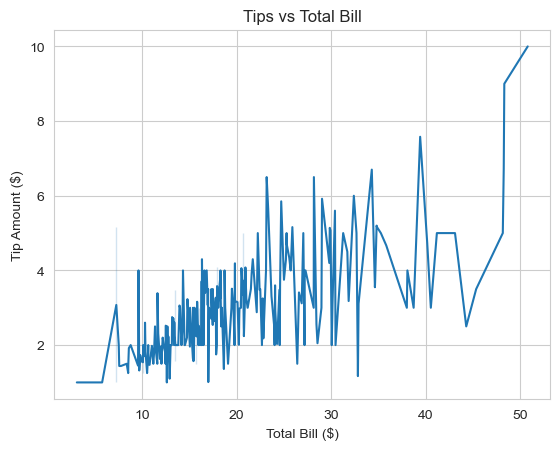

In [12]:
# Line plot using seaborn library
sns.set_style('whitegrid') # setting grid style

# sns.set_style('darkgrid')
# sns.set_style('dark')

tipgraph = sns.lineplot(data=tips,
             x = 'total_bill',
             y = 'tip')

tipgraph.set(title = 'Tips vs Total Bill',
             xlabel = 'Total Bill ($)',
             ylabel = 'Tip Amount ($)')

[Text(0.5, 1.0, 'Tips vs Total Bill'),
 Text(0.5, 0, 'Total Bill ($)'),
 Text(0, 0.5, 'Tip Amount ($)')]

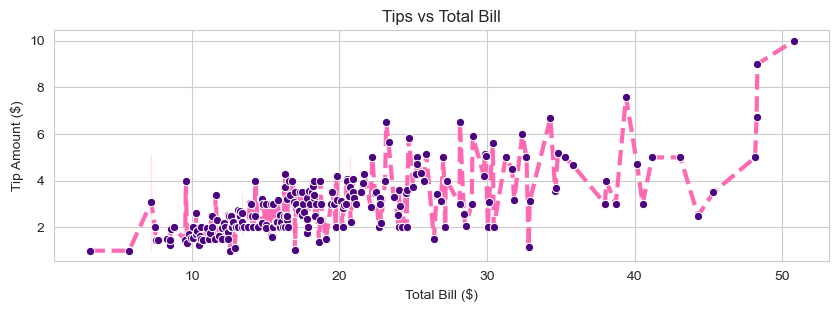

In [ ]:
fig = plt.subplots(figsize = (10, 3))

# Formatting graph by adding color, linestyle, marker etc.
tipgraph = sns.lineplot(data = tips,
                        x = 'total_bill',
                        y = 'tip',
                        color = 'hotpink',
                        linestyle = '--',
                        linewidth = 3,
                        marker = 'o',
                        markerfacecolor = 'indigo')

tipgraph.set(title = 'Tips vs Total Bill',
             xlabel = 'Total Bill ($)',
             ylabel = 'Tip Amount ($)')

[Text(0.5, 1.0, 'Tips vs Total Bill'),
 Text(0.5, 0, 'Total Bill ($)'),
 Text(0, 0.5, 'Tip Amount ($)')]

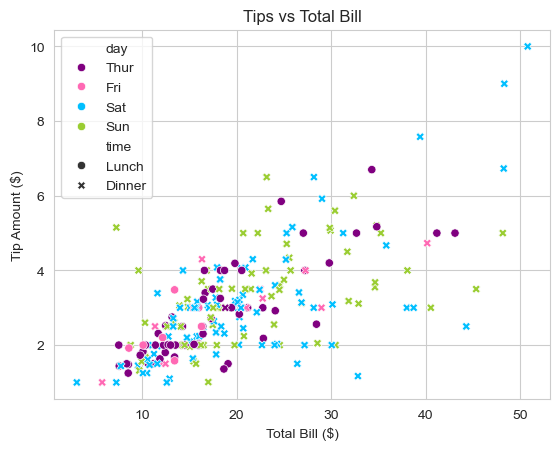

In [18]:
# Formatting graph by adding color, linestyle, marker etc.
tipgraph = sns.scatterplot(data = tips,
                        x = 'total_bill',
                        y = 'tip',
                        style = 'time',
                        hue = 'day',
                        palette = ['purple', 'hotpink', 'deepskyblue', 'yellowgreen'])

tipgraph.set(title = 'Tips vs Total Bill',
             xlabel = 'Total Bill ($)',
             ylabel = 'Tip Amount ($)')

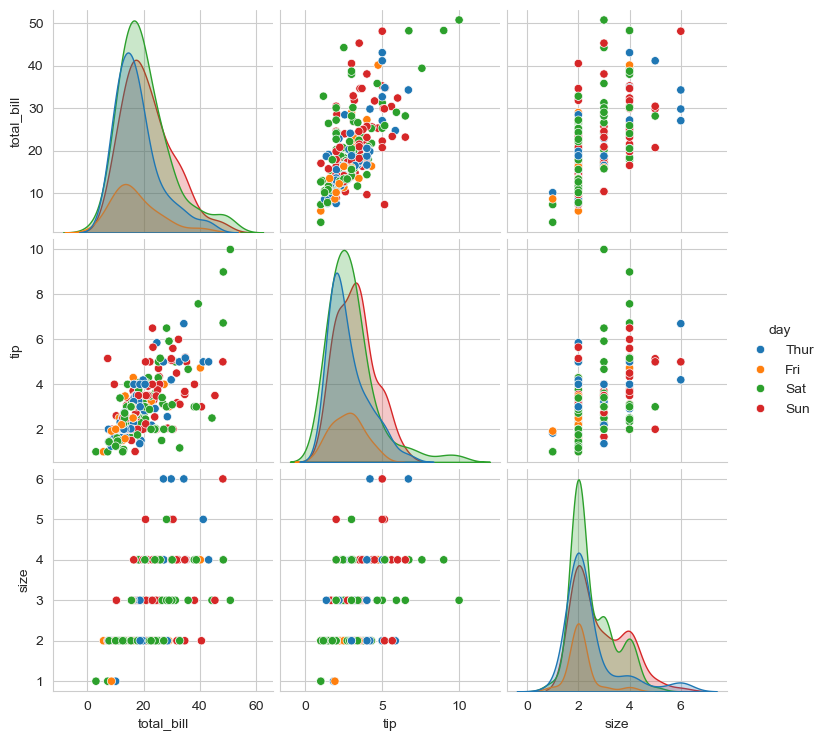

In [ ]:
# Exploring the potential relationships between numerical/countinous features in the dataset
sns.pairplot(data = tips,
             hue = 'day')

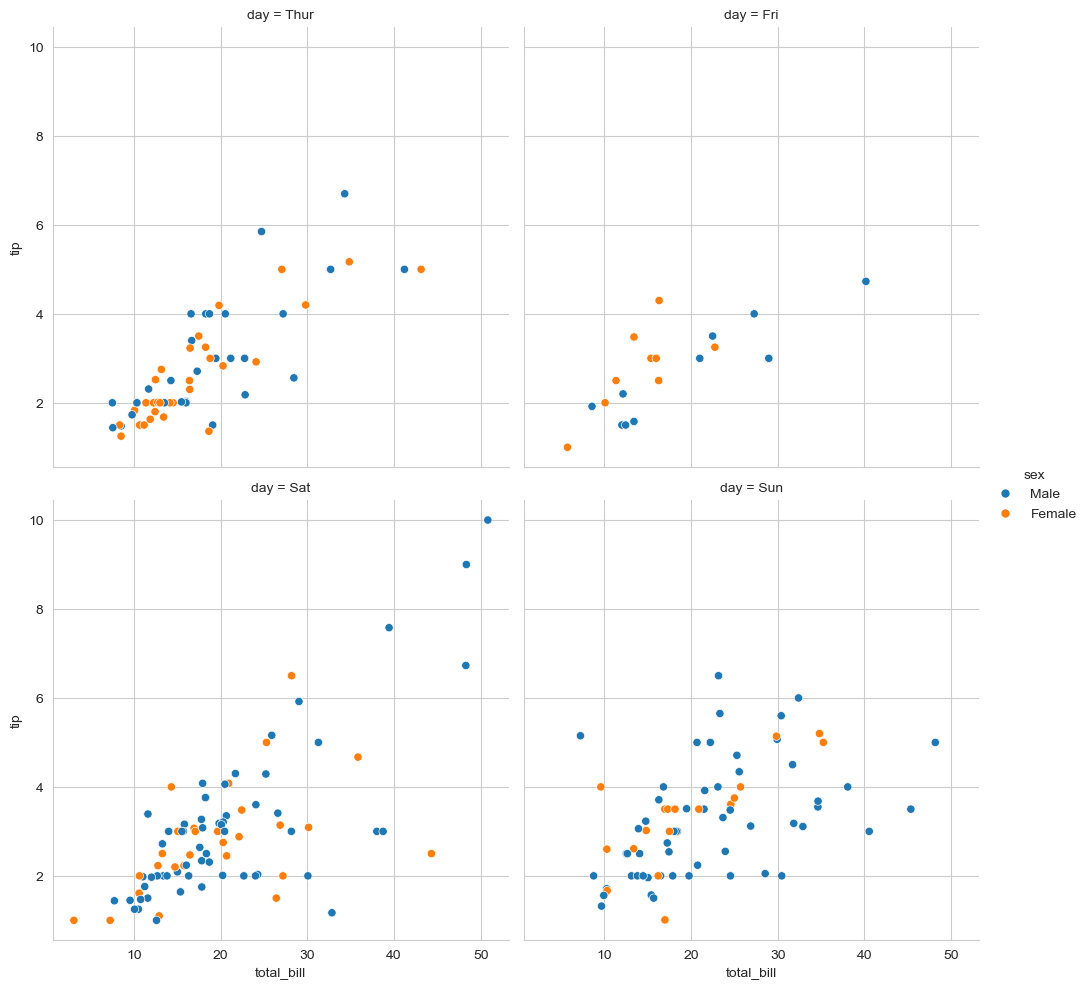

In [26]:
daysplot = sns.relplot(
    data = tips,
    x = 'total_bill',
    y = 'tip',
    hue = 'sex', # Color points based on gender (Male/Female)
    col = 'day', # Create separate plots for each day
    kind = 'scatter', # Specify scatter plot type
    col_wrap = 2 # Arrange facet plots in 2 columns
)

When you use sns.relplot(), it automatically plots the data without needing to explicitly call another function like sns.scatterplot() or sns.lineplot(). This happens because: relplot() is a figure-level function, meaning it creates a FacetGrid and then applies the appropriate plotting function (sns.scatterplot or sns.lineplot) under the hood. You specify the kind parameter (kind="scatter" or kind="line"), and Seaborn takes care of calling the appropriate function.

In [ ]:
# Importing the Plotly library for creating interactive plots
import plotly.graph_objects as go

x1 = np.array(['Luffy', 'Zoro', 'Nami', 'Usopp','Sanji'])
y1 = np.array([110, 180, 240, 99, 220])

In [ ]:
# Creating an empty figure object
graph = go.Figure()

# Adding a bar chart trace to the figure
graph.add_trace(go.Bar(x=x1,y=y1))

# Updating layout to customize the graph
graph.update_layout(title = 'Pirate Scores',
                    xaxis_title = 'Pirates',
                    yaxis_title = 'Score',
                    title_x = 0.5, # location of title horizontally
                    title_y = 0.90) # location of title vertically

In [ ]:
graph = go.Figure()

# Adding a scatter plot trace (for individual data points)
graph.add_trace(go.Scatter(x=x1,
                           y=y1,
                           mode='markers', # Displaying points as markers
                           marker = dict(
                               size = 15,
                               color = 'hotpink',
                               opacity = 1,
                               line = dict(width = 5, color = 'purple') # Border styling (thickness & color)
                           )))

graph.update_layout(title = 'Interactive Pirate Plot',
                    xaxis_title = 'Pirates',
                    yaxis_title = 'Scores',
                    width =500, # Setting the width of the figure
                    height = 500) # Setting the height of the figure

In [ ]:
# Importing WordCloud for generating word clouds
from wordcloud import WordCloud
df = pd.read_csv('https://raw.githubusercontent.com/prasertcbs/basic-dataset/master/movie_quotes.csv',
                 on_bad_lines = 'skip') # Skipping any bad lines (malformed rows) in the CSV file
df

,quote,movie,type,year
0,"Do, or do not. There is no try.",Star Wars: Episode V - The Empire Strikes Back,movie,1890
1,Listen to them. Children of the night. What mu...,Dracula,movie,1931
2,It's alive! It's alive!,Frankenstein,movie,1931
3,"Oh, no, it wasn't the airplanes. It was Beauty...",King Kong,movie,1933
4,"Magic Mirror on the wall, who is the fairest o...",Snow White and the Seven Dwarves,movie,1937
...,...,...,...,...
727,I didn't know if you were lost. Stick with me....,Us,movie,2019
728,This guy's awesome! He's holding his own while...,Dragon Ball Super: Broly,movie,2019
729,"Murder is murder, it don’t matter who you are.",Black and Blue,movie,2019
730,You know what a lion is? A lion is a strong an...,Between Two Ferns: The Movie,movie,2019


(-0.5, 399.5, 199.5, -0.5)

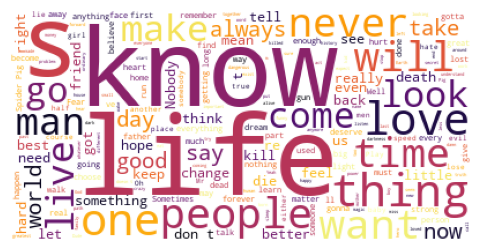

In [ ]:
# Creating a single string by joining all movie quotes from the 'quote' column
text = " ".join(each for each in df.quote)

# Generating the word cloud
wordcloud = WordCloud(background_color='white', # Setting background color to white
                      colormap = 'inferno').generate(text) # Using the 'inferno' color scheme for styling and then Generating the word cloud using the combined text

fig, ax = plt.subplots(figsize = (7,3))

# Displaying the generated word cloud on the axis
ax.imshow(wordcloud)
ax.axis('off') # Hides the axis for better visualization

In [ ]:
# venn2: Creates a two-set Venn diagram
# venn2_circles: Adds outlines (circles) to a Venn diagram for better visualization
# venn2_unweighted: Generates a Venn diagram where circle sizes are equal, regardless of set sizes
from matplotlib_venn import venn2, venn2_circles, venn2_unweighted

In [52]:
A = set(["apple", "banana", "watermelon"])
B = set(["pumpkin", "blueberry", "apple", "key lime"])

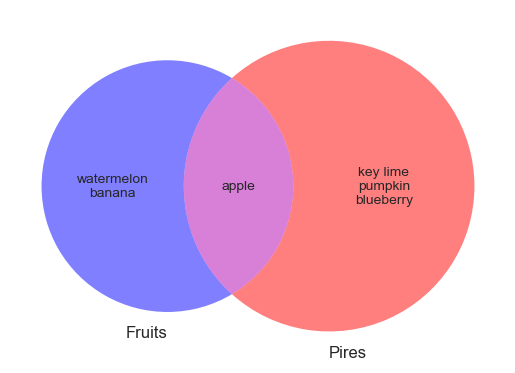

In [ ]:
# Creating a two-set Venn diagram
diagram = venn2([A,B],
                set_labels = ('Fruits', 'Pires'), # Labels for each set
                set_colors = ('blue', 'red'), # Assigning colors to each set
                alpha = 0.5) # Adjusting transparency (0 = fully transparent, 1 = fully opaque)

# Updating the text inside different sections of the Venn diagram

# Elements that are only in A (A - B)
diagram.get_label_by_id('10').set_text('\n'.join(A-B))

# Elements that are in both A and B (A ∩ B)
diagram.get_label_by_id('11').set_text('\n'.join(A&B))

# Elements that are only in B (B - A)
diagram.get_label_by_id('01').set_text('\n'.join(B-A))